In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
ethiopia = pd.read_csv('../data/ethiopia_clean.csv')
kenya = pd.read_csv('../data/kenya_clean.csv')
nigeria = pd.read_csv('../data/nigeria_clean.csv')
sudan = pd.read_csv('../data/sudan_clean.csv')
tanzania = pd.read_csv('../data/tanzania_clean.csv')

In [11]:
all_countries = pd.concat([ethiopia, kenya, nigeria, sudan, tanzania], ignore_index=True)

print(f"Loaded {len(all_countries)} rows from 5 countries")
print(f"Countries: {all_countries['Country'].unique()}")

Loaded 20540 rows from 5 countries
Countries: <StringArray>
['Ethiopia', 'Kenya', 'Nigeria', 'Sudan', 'Tanzania']
Length: 5, dtype: str


In [12]:
monthly_temp = all_countries.groupby(['Date', 'Country'])['T2M'].mean().reset_index()

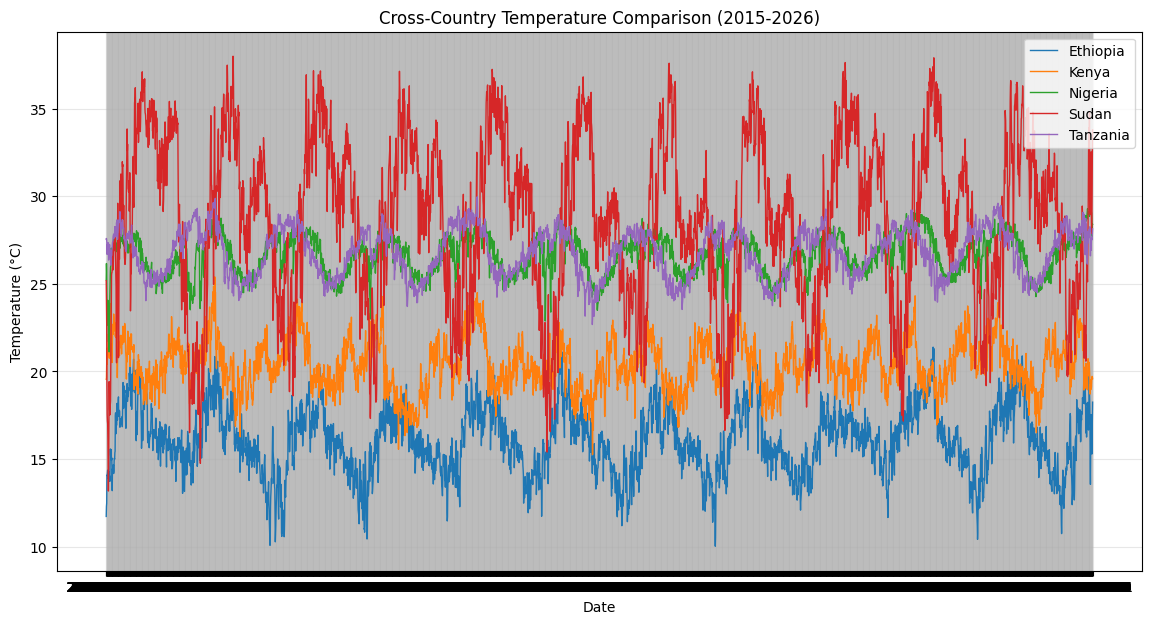

In [13]:
plt.figure(figsize=(14, 7))
for country in all_countries['Country'].unique():
    country_data = monthly_temp[monthly_temp['Country'] == country]
    plt.plot(country_data['Date'], country_data['T2M'], label=country, linewidth=1)

plt.title('Cross-Country Temperature Comparison (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
summary = all_countries.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).round(2)
print("Average Temperature by Country (°C):")
print(summary.sort_values('mean', ascending=False))

Average Temperature by Country (°C):
           mean  median   std
Country                      
Sudan     28.76   29.16  4.68
Tanzania  26.80   26.99  1.33
Nigeria   26.66   26.82  1.12
Kenya     20.43   20.36  1.44
Ethiopia  16.07   16.04  1.90


Average Precipitation by Country (mm/day):
          mean  median   std
Country                     
Nigeria   4.21    1.84  7.27
Tanzania  3.74    0.64  8.00
Ethiopia  3.63    0.82  6.29
Kenya     1.47    0.38  3.18
Sudan     0.64    0.00  3.06


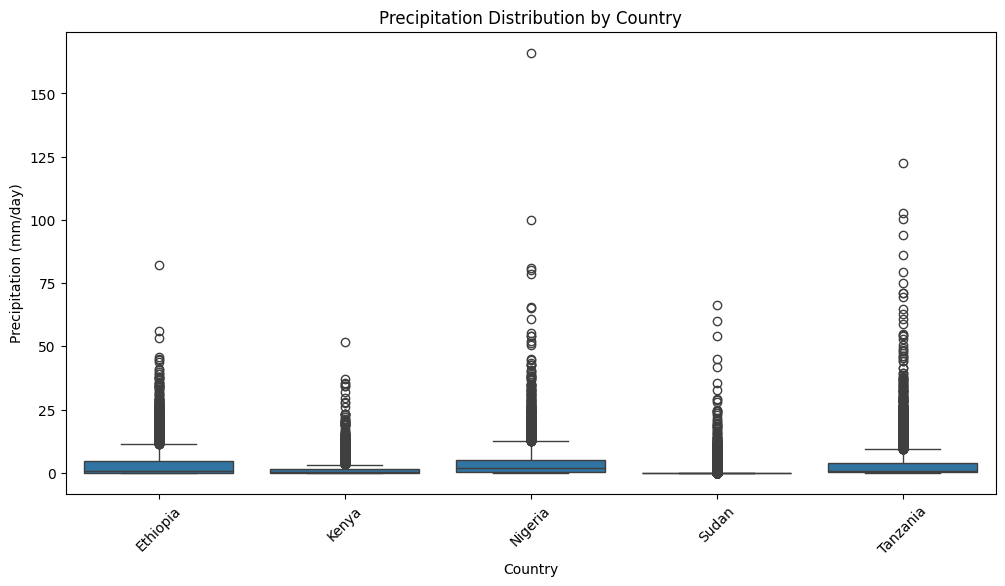

In [15]:
precip_summary = all_countries.groupby('Country')['PRECTOTCORR'].agg(['mean', 'median', 'std']).round(2)
print("Average Precipitation by Country (mm/day):")
print(precip_summary.sort_values('mean', ascending=False))

plt.figure(figsize=(12, 6))
sns.boxplot(data=all_countries, x='Country', y='PRECTOTCORR')
plt.title('Precipitation Distribution by Country')
plt.xlabel('Country')
plt.ylabel('Precipitation (mm/day)')
plt.xticks(rotation=45)
plt.show()

In [16]:
vulnerability = all_countries.groupby('Country').agg({
    'T2M': 'mean',
    'PRECTOTCORR': ['mean', 'std']
}).round(2)

vulnerability.columns = ['Avg_Temp', 'Avg_Precip', 'Precip_Variability']

vulnerability['Temp_Rank'] = vulnerability['Avg_Temp'].rank(ascending=False)
vulnerability['Precip_Rank'] = vulnerability['Avg_Precip'].rank(ascending=True)
vulnerability['Vulnerability_Score'] = (vulnerability['Temp_Rank'] + vulnerability['Precip_Rank']) / 2
vulnerability = vulnerability.sort_values('Vulnerability_Score')

print("=== CLIMATE VULNERABILITY RANKING ===")
print(vulnerability[['Avg_Temp', 'Avg_Precip', 'Vulnerability_Score']])

=== CLIMATE VULNERABILITY RANKING ===
          Avg_Temp  Avg_Precip  Vulnerability_Score
Country                                            
Sudan        28.76        0.64                  1.0
Kenya        20.43        1.47                  3.0
Tanzania     26.80        3.74                  3.0
Ethiopia     16.07        3.63                  4.0
Nigeria      26.66        4.21                  4.0
